# EDA Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
%matplotlib inline

## importing Data

In [2]:
dim_branch = pd.read_csv("cleaned_data/cleaned_dim_branch.csv")
dim_date = pd.read_csv("cleaned_data/cleaned_dim_date.csv")
dim_employee = pd.read_csv("cleaned_data/cleaned_dim_employee.csv")
dim_product = pd.read_csv("cleaned_data/cleaned_dim_product.csv")
fact_sales = pd.read_csv("cleaned_data/cleaned_fact_sales.csv")

In [3]:
dim_branch.head()

,BranchKey,BranchName,City,Region,ManagerName,OpeningDate,MonthlyTarget,SquareMeters
0,1,فرع الرياض,الرياض,الوسطى,خالد العتيبي,2019-03-15,800000,450
1,2,فرع جدة,جدة,الغربية,فهد الزهراني,2020-07-01,700000,380
2,3,فرع الدمام,الدمام,الشرقية,سعد القحطاني,2021-01-10,600000,320
3,4,فرع مكة,مكة المكرمة,الغربية,ناصر الشهراني,2022-05-20,500000,280
4,5,فرع المدينة,المدينة المنورة,الغربية,بندر الدوسري,2023-09-01,400000,250


In [4]:
dim_date.head()

,DateKey,Date,Year,Quarter,Month,Day,MonthNameAr,DayNameAr,IsWeekend,IsHoliday
0,1,2024-01-01,2024,1,1,1,يناير,الإثنين,False,False
1,2,2024-01-02,2024,1,1,2,يناير,الثلاثاء,False,False
2,3,2024-01-03,2024,1,1,3,يناير,الأربعاء,False,False
3,4,2024-01-04,2024,1,1,4,يناير,الخميس,False,False
4,5,2024-01-05,2024,1,1,5,يناير,الجمعة,True,False


In [5]:
dim_employee.head()

,EmployeeKey,FullNameAr,JobTitle,BranchKey,HireDate,MonthlyTarget,PhoneNumber,Email
0,1,جلاء آل معيض,مدير فرع,5,2024-09-20,0,غير متوفر,tbwlmshwl@example.net
1,2,ضاحي الشايع,مندوب مبيعات,2,2022-02-11,0,غير متوفر,lhkyrrmy@example.com
2,3,أفنان العجلان,أخصائي مخزون,5,2023-06-19,0,غير متوفر,knwtyl@example.com
3,4,قنوع آل معيض,مندوب مبيعات,1,2022-05-04,0,غير متوفر,oal-myd@example.net
4,5,حيدر آل عواض,مندوب مبيعات,1,2024-05-15,45247,غير متوفر,qal-sltn@example.org


In [6]:
dim_product.head()

,ProductKey,ProductName,Category,SubCategory,UnitCost,UnitPrice,Supplier,StockQuantity,ReorderPoint,IsActive
0,1,Recusandae هواتف ذكية,إلكترونيات,هواتف ذكية,292,336.65,"آل بن ظافر, آل عايض and أبو داوود",38,39,True
1,2,Ad هواتف ذكية,إلكترونيات,هواتف ذكية,432,544.65,بن لادن and Sons,282,38,True
2,3,Nam هواتف ذكية,إلكترونيات,هواتف ذكية,26,32.30,أبا الخيل and Sons,460,25,True
3,4,Recusandae هواتف ذكية,إلكترونيات,هواتف ذكية,112,151.72,بقشان Group,341,33,True
4,5,Veritatis هواتف ذكية,إلكترونيات,هواتف ذكية,291,411.83,"الجابر, الحكير and آل سعود",208,99,True


In [7]:
fact_sales.head()

,SaleKey,DateKey,ProductKey,BranchKey,EmployeeKey,Quantity,UnitPrice,DiscountRate,TotalAmount,CostAmount,ProfitAmount,OrderStatus,PaymentMethod,UnitCost
0,1,335,578,3,44,12,478.59,0.00,5743.080,4656,1087.080,مكتمل,مدى,388
1,2,252,748,1,5,7,566.72,0.05,3768.688,3143,625.688,مكتمل,مدى,449
2,3,473,162,2,26,1,414.40,0.00,414.400,294,120.400,مكتمل,نقدي,294
3,4,187,675,2,89,2,223.29,0.05,424.251,336,88.251,مكتمل,نقدي,168
4,6,424,284,1,123,9,23.67,0.00,213.030,171,42.030,مكتمل,بطاقة,19


## EDA

In [8]:
fact_sales.head()

,SaleKey,DateKey,ProductKey,BranchKey,EmployeeKey,Quantity,UnitPrice,DiscountRate,TotalAmount,CostAmount,ProfitAmount,OrderStatus,PaymentMethod,UnitCost
0,1,335,578,3,44,12,478.59,0.00,5743.080,4656,1087.080,مكتمل,مدى,388
1,2,252,748,1,5,7,566.72,0.05,3768.688,3143,625.688,مكتمل,مدى,449
2,3,473,162,2,26,1,414.40,0.00,414.400,294,120.400,مكتمل,نقدي,294
3,4,187,675,2,89,2,223.29,0.05,424.251,336,88.251,مكتمل,نقدي,168
4,6,424,284,1,123,9,23.67,0.00,213.030,171,42.030,مكتمل,بطاقة,19


In [9]:
fact_sales.shape

(47500, 14)

- Outlier descovery

{'whiskers': [<matplotlib.lines.Line2D at 0x1fa7eafca70>,
 'caps': [<matplotlib.lines.Line2D at 0x1fa7eafcfb0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1fa7eadbb90>],
 'medians': [<matplotlib.lines.Line2D at 0x1fa7eafd4c0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1fa7eafd760>],
 'means': []}

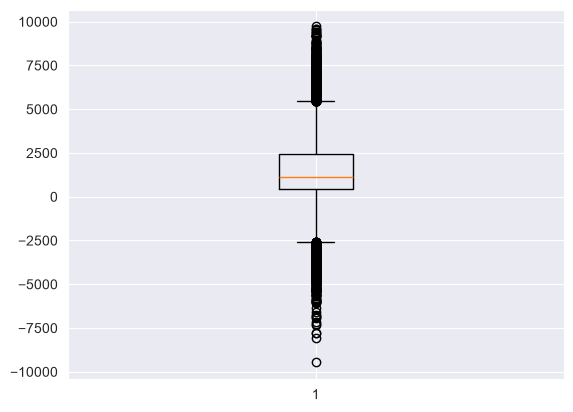

In [10]:
plt.boxplot(data=fact_sales,x="TotalAmount")

- IQR method

In [11]:
Q1 = fact_sales["TotalAmount"].quantile(0.25)
Q3 = fact_sales["TotalAmount"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

- OutLiers

In [12]:
fact_sales_outLiers = fact_sales[(fact_sales["TotalAmount"] >= upper) | (fact_sales["TotalAmount"] <= lower)]
fact_sales_outLiers.head()

,SaleKey,DateKey,ProductKey,BranchKey,EmployeeKey,Quantity,UnitPrice,DiscountRate,TotalAmount,CostAmount,ProfitAmount,OrderStatus,PaymentMethod,UnitCost
0,1,335,578,3,44,12,478.59,0.00,5743.080,4656,1087.080,مكتمل,مدى,388
33,35,444,546,3,44,11,584.40,0.00,6428.400,4554,1874.400,مكتمل,نقدي,414
100,102,447,135,1,94,14,443.54,0.00,6209.560,4788,1421.560,مكتمل,مدى,342
140,142,252,523,1,63,10,572.07,0.00,5720.700,4120,1600.700,مكتمل,تمارا,412
173,179,11,690,1,81,10,656.79,0.05,6239.505,4870,1369.505,مكتمل,مدى,487


In [13]:
fact_sales_outLiers.shape

(1590, 14)

- dataset without *Outliers*

In [14]:
fact_sales_no_outlier = fact_sales[(fact_sales["TotalAmount"] >= lower)&(fact_sales["TotalAmount"] <= upper)].reindex()

fact_sales_no_outlier

,SaleKey,DateKey,ProductKey,BranchKey,EmployeeKey,Quantity,UnitPrice,DiscountRate,TotalAmount,CostAmount,ProfitAmount,OrderStatus,PaymentMethod,UnitCost
1,2,252,748,1,5,7,566.72,0.05,3768.688,3143,625.688,مكتمل,مدى,449
2,3,473,162,2,26,1,414.40,0.00,414.400,294,120.400,مكتمل,نقدي,294
3,4,187,675,2,89,2,223.29,0.05,424.251,336,88.251,مكتمل,نقدي,168
4,6,424,284,1,123,9,23.67,0.00,213.030,171,42.030,مكتمل,بطاقة,19
5,7,167,593,1,81,2,452.36,0.15,769.012,722,47.012,مكتمل,بطاقة,361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47495,49996,44,620,4,98,8,437.16,0.20,2797.824,2936,-138.176,مكتمل,نقدي,367
47496,49997,442,784,3,44,7,419.68,0.00,2937.760,2072,865.760,مكتمل,أبل باي,296
47497,49998,217,661,3,44,-6,264.95,0.15,-1351.245,-1260,-91.245,ملغي,بطاقة,210
47498,49999,521,123,3,44,2,131.86,0.10,237.348,202,35.348,مكتمل,تمارا,101


- calc percentage of outliears in data

In [15]:
main_data = 5100
outlier = 1731
no_outlier = 49269 

out_val = ((outlier / main_data)*100)
without_val = ((no_outlier / main_data)*100)
print(f"data with outlier {int(out_val)}%")
print(f"data without outlier {int(without_val)}%")


data with outlier 33%
data without outlier 966%


*NOTE:*
- When reviewing the outlier values, 
- I found that they are real values and that there are people who buy large quantities,
- and some of these people return them or cancel the order before receiving or completing it.
- The percentage of outliers in the data is 33%, and this is the percentage I deleted previously, but after the review,
- I will keep it.

*Next:*
- merge `dim_date` & `fact_sales`

In [16]:
fact_sales_sorted = fact_sales.sort_values(by="DateKey")
fact_sales_sorted.shape

(47500, 14)

In [17]:
df=pd.merge(fact_sales_sorted , dim_date, on="DateKey", how="inner")
print(df.isna().sum())
print(df.shape)

SaleKey          0
DateKey          0
ProductKey       0
BranchKey        0
EmployeeKey      0
Quantity         0
UnitPrice        0
DiscountRate     0
TotalAmount      0
CostAmount       0
ProfitAmount     0
OrderStatus      0
PaymentMethod    0
UnitCost         0
Date             0
Year             0
Quarter          0
Month            0
Day              0
MonthNameAr      0
DayNameAr        0
IsWeekend        0
IsHoliday        0
dtype: int64
(47500, 23)


In [18]:
df.head()

,SaleKey,DateKey,ProductKey,BranchKey,EmployeeKey,Quantity,UnitPrice,DiscountRate,TotalAmount,CostAmount,...,UnitCost,Date,Year,Quarter,Month,Day,MonthNameAr,DayNameAr,IsWeekend,IsHoliday
0,13026,1,477,2,68,10,364.39,0.0,3643.900,2770,...,277,2024-01-01,2024,1,1,1,يناير,الإثنين,False,False
1,48596,1,643,4,54,7,398.80,0.0,2791.600,1932,...,276,2024-01-01,2024,1,1,1,يناير,الإثنين,False,False
2,32637,1,270,2,67,1,99.49,0.0,99.490,83,...,83,2024-01-01,2024,1,1,1,يناير,الإثنين,False,False
3,17227,1,562,2,103,7,515.54,0.0,3608.780,2779,...,397,2024-01-01,2024,1,1,1,يناير,الإثنين,False,False
4,33307,1,695,1,123,6,515.49,0.1,2783.646,2280,...,380,2024-01-01,2024,1,1,1,يناير,الإثنين,False,False


In [19]:
df.columns

Index(['SaleKey', 'DateKey', 'ProductKey', 'BranchKey', 'EmployeeKey',
       'Quantity', 'UnitPrice', 'DiscountRate', 'TotalAmount', 'CostAmount',
       'ProfitAmount', 'OrderStatus', 'PaymentMethod', 'UnitCost', 'Date',
       'Year', 'Quarter', 'Month', 'Day', 'MonthNameAr', 'DayNameAr',
       'IsWeekend', 'IsHoliday'],
      dtype='str')

###  التحليل الوصفي (Univariate Analysis)

In [20]:
df.describe(include=np.number).round(2)

,SaleKey,DateKey,ProductKey,BranchKey,EmployeeKey,Quantity,UnitPrice,DiscountRate,TotalAmount,CostAmount,ProfitAmount,UnitCost,Year,Quarter,Month,Day
count,47500.00,47500.00,47500.00,47500.00,47500.00,47500.00,47500.00,47500.00,47500.00,47500.00,47500.00,47500.00,47500.00,47500.00,47500.00,47500.00
mean,25009.82,274.08,401.78,2.50,65.80,5.07,334.18,0.07,1577.16,1331.93,245.23,262.33,2024.33,2.18,5.54,15.67
std,14442.97,157.94,231.60,1.33,34.12,3.80,190.74,0.07,1642.20,1351.70,458.29,143.44,0.47,1.07,3.32,8.74
min,1.00,1.00,1.00,1.00,2.00,-14.00,6.67,0.00,-9466.52,-6874.00,-6090.00,5.00,2024.00,1.00,1.00,1.00
25%,12495.75,137.00,199.00,1.00,44.00,2.00,165.21,0.00,429.91,382.00,40.50,137.00,2024.00,1.00,3.00,8.00
50%,25003.50,275.00,404.00,2.00,68.00,5.00,334.37,0.05,1149.27,984.00,151.01,265.00,2024.00,2.00,5.00,16.00
75%,37534.25,411.00,602.00,3.00,94.00,8.00,500.49,0.15,2443.63,2064.00,395.80,386.00,2025.00,3.00,8.00,23.00
max,50000.00,546.00,800.00,5.00,126.00,14.00,702.19,0.20,9728.60,6986.00,3080.00,500.00,2025.00,4.00,12.00,31.00


Text(0.5, 1.0, 'TotalAmount distribution')

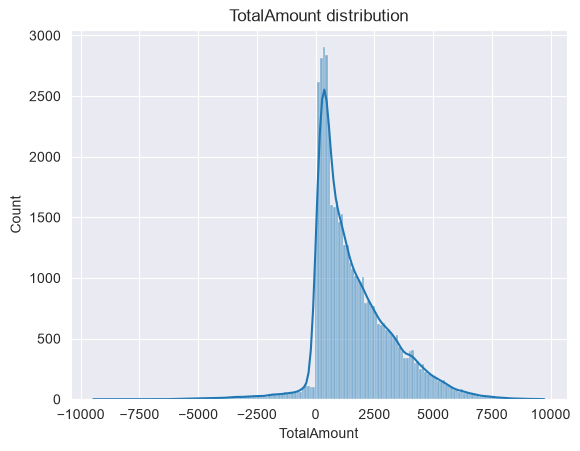

In [21]:
sns.histplot(data=df , x="TotalAmount", kde=True)
plt.title("TotalAmount distribution")

- Notice that the small amounts less than 2000 are the ones that repeat more often.


Text(0.5, 1.0, 'ProfitAmount distribution')

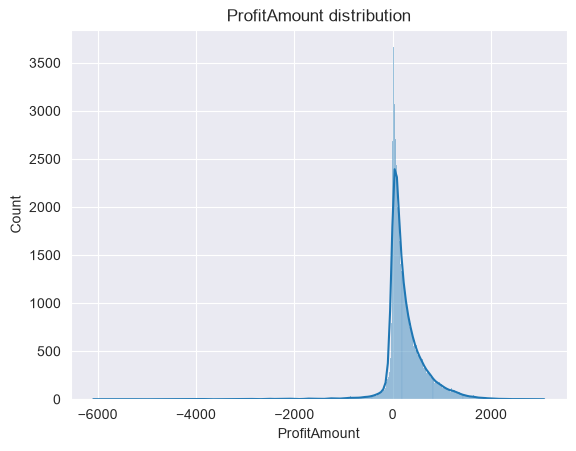

In [22]:
sns.histplot(data=df , x="ProfitAmount", kde=True)
plt.title("ProfitAmount distribution")

-There are a few negative values, but the maximum value is positive, and here I am in profit.

- *`ProfitAmount` & `TotalAmount` The reason for the negative values in each of them must be identified*

- It could be because of the big discounts.

###  العلاقات الثنائية (Bivariate Analysis)  / relations


In [23]:
df_specific = df.loc[:,['SaleKey', 'BranchKey', 'ProductKey', 'Quantity', 'UnitPrice', 'DiscountRate', 'TotalAmount', 'CostAmount', 'ProfitAmount']]

- *Correlation*

<Axes: >

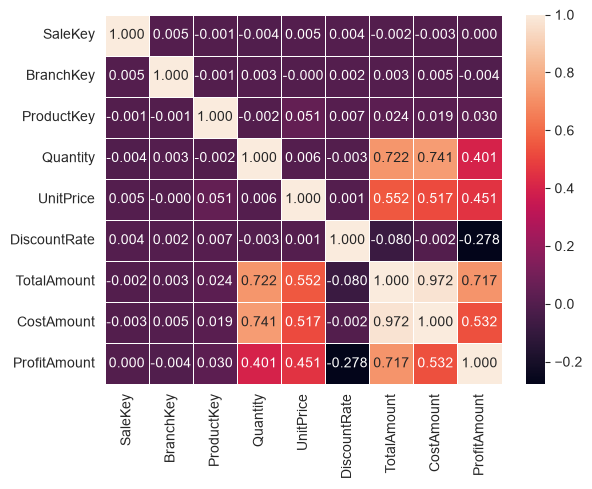

In [24]:
sns.heatmap(df_specific.corr(), annot=True, fmt=".3f", linewidths=0.5)

*Positive Correlation:*
- `Quantity` & `CostAmount`
- `Quantity` & `TotalAmount`
- `UnitPrice` & `ProfitAmount`
- `UnitPrice` & `CostAmount`
- `UnitPrice` & `TotalAmount`
- `TotalAmount` & `ProfitAmount`
- `TotalAmount` & `CostAmount`


*Negative Correlation:*
- `DiscountRate` & `ProfitAmount`
- `DiscountRate` & `TotalAmount`

<mark>Relation of Quantity per CostAmount</mark>

Text(0, 0.5, 'TotalAmount')

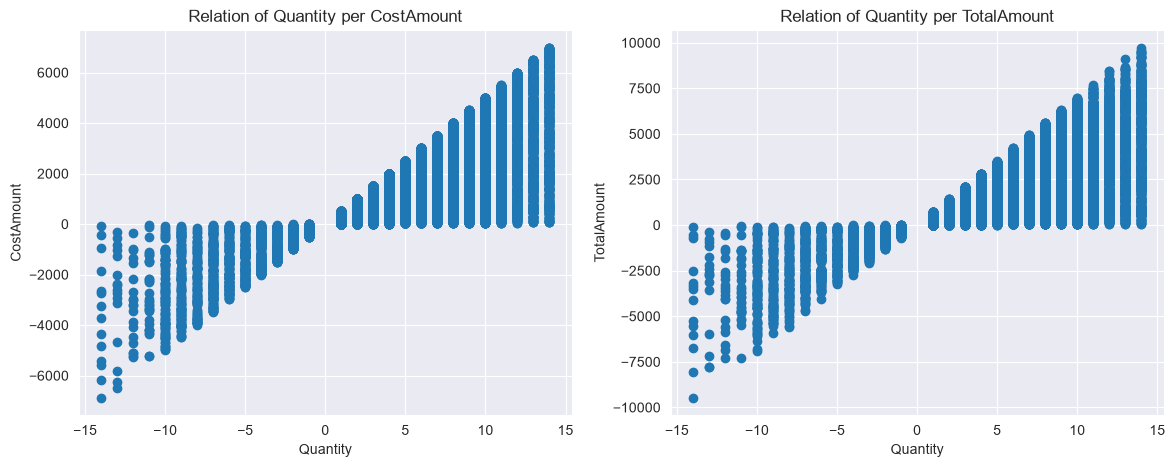

In [25]:
fig ,ax = plt.subplots(1,2,figsize=(14,5))

ax[0].scatter(x=df_specific["Quantity"], y=df_specific["CostAmount"])
ax[0].set_title("Relation of Quantity per CostAmount")
ax[0].set_xlabel('Quantity')
ax[0].set_ylabel('CostAmount')


ax[1].scatter(x=df_specific["Quantity"], y=df_specific["TotalAmount"])
ax[1].set_title("Relation of Quantity per TotalAmount")
ax[1].set_xlabel('Quantity')
ax[1].set_ylabel('TotalAmount')

<mark>Relation of UnitPrice per ProfitAmount, CostAmount, TotalAmount</mark>

Text(0.5, 1.0, 'relation of UnitPrice per ProfitAmount')

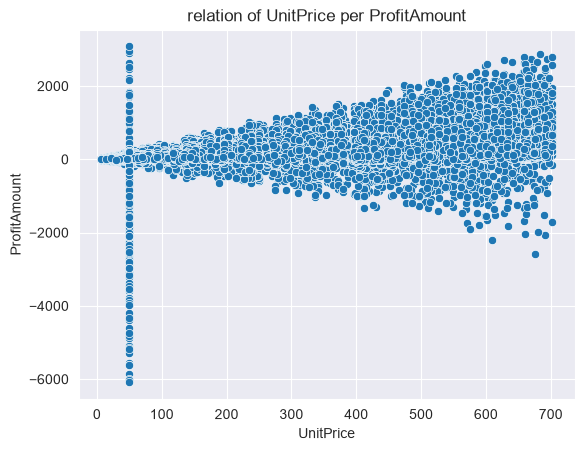

In [26]:
sns.scatterplot(x=df_specific["UnitPrice"], y=df_specific["ProfitAmount"])
plt.title("relation of UnitPrice per ProfitAmount")

Text(0.5, 1.0, 'relation of UnitPrice per CostAmount')

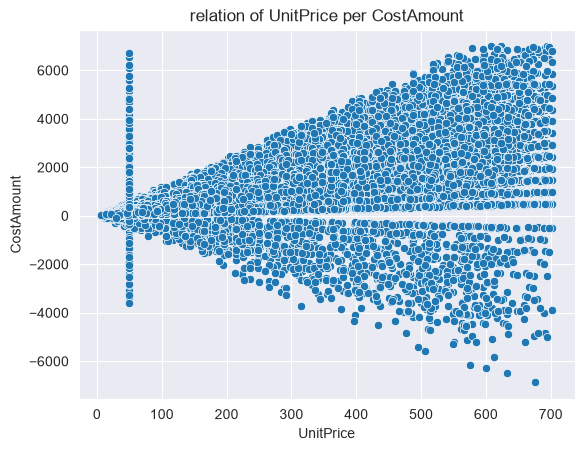

In [27]:
sns.scatterplot(x=df_specific["UnitPrice"], y=df_specific["CostAmount"])
plt.title("relation of UnitPrice per CostAmount")

Text(0.5, 1.0, 'relation of UnitPrice per TotalAmount')

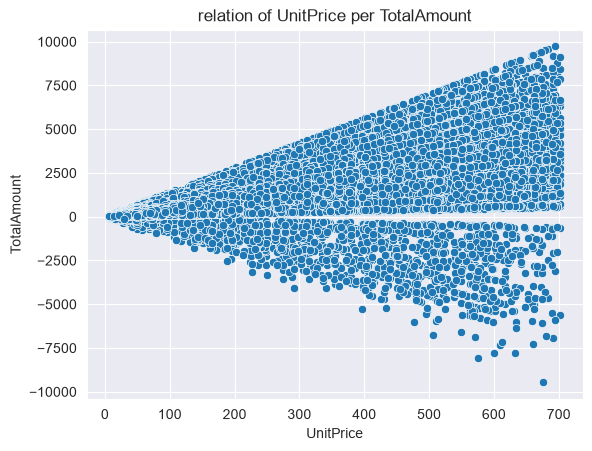

In [28]:
sns.scatterplot(x=df_specific["UnitPrice"], y=df_specific["TotalAmount"])
plt.title("relation of UnitPrice per TotalAmount")

<mark>Relation of TotalAmount per ProfitAmount, CostAmount</mark>

Text(0.5, 1.0, 'relation of TotalAmount per ProfitAmount')

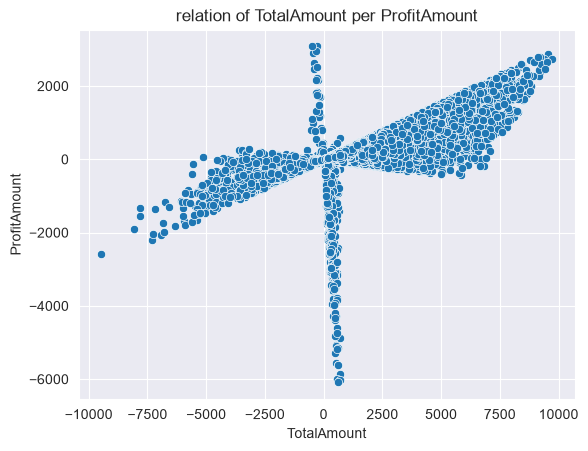

In [29]:
sns.scatterplot(x=df_specific["TotalAmount"], y=df_specific["ProfitAmount"])
plt.title("relation of TotalAmount per ProfitAmount")

Text(0.5, 1.0, 'relation of TotalAmount per CostAmount')

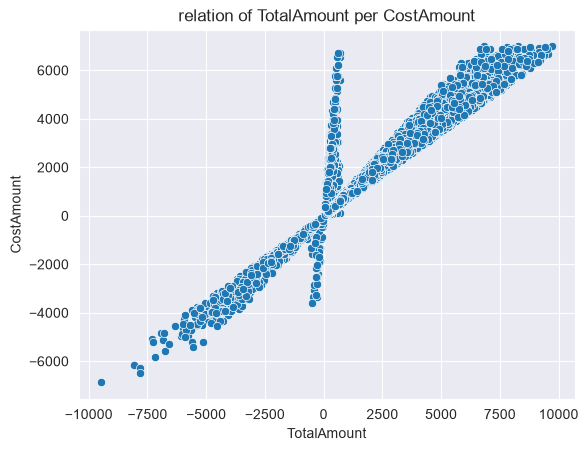

In [30]:
sns.scatterplot(x=df_specific["TotalAmount"], y=df_specific["CostAmount"])
plt.title("relation of TotalAmount per CostAmount")

<mark>Relation of DiscountRate per ProfitAmount, CostAmount</mark>

Text(0.5, 1.0, 'relation of DiscountRate per ProfitAmount')

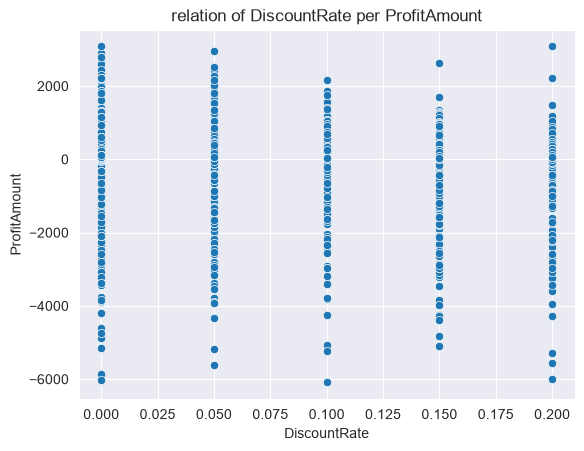

In [31]:
sns.scatterplot(x=df_specific["DiscountRate"], y=df_specific["ProfitAmount"])
plt.title("relation of DiscountRate per ProfitAmount")

*Relations NOTE:*

- `Quantity` has a positive effect on `CostAmount` & `TotalAmount`

- `DiscoutRate` has a negative effect on `ProfitAmount`

#### Analysis of negative values in `ProfitAmount`

In [32]:
fact_sales.head()

,SaleKey,DateKey,ProductKey,BranchKey,EmployeeKey,Quantity,UnitPrice,DiscountRate,TotalAmount,CostAmount,ProfitAmount,OrderStatus,PaymentMethod,UnitCost
0,1,335,578,3,44,12,478.59,0.00,5743.080,4656,1087.080,مكتمل,مدى,388
1,2,252,748,1,5,7,566.72,0.05,3768.688,3143,625.688,مكتمل,مدى,449
2,3,473,162,2,26,1,414.40,0.00,414.400,294,120.400,مكتمل,نقدي,294
3,4,187,675,2,89,2,223.29,0.05,424.251,336,88.251,مكتمل,نقدي,168
4,6,424,284,1,123,9,23.67,0.00,213.030,171,42.030,مكتمل,بطاقة,19


- to see if there are `ProfitAmount` less than zero, with high `DiscountRate` >= 0.4

In [33]:
Negative_fact= fact_sales.loc[fact_sales["ProfitAmount"] <= 0]
Negative_fact

,SaleKey,DateKey,ProductKey,BranchKey,EmployeeKey,Quantity,UnitPrice,DiscountRate,TotalAmount,CostAmount,ProfitAmount,OrderStatus,PaymentMethod,UnitCost
13,15,1,177,3,44,3,284.75,0.15,726.1125,738,-11.8875,مكتمل,تمارا,246
34,36,121,633,5,75,11,37.32,0.20,328.4160,341,-12.5840,مكتمل,نقدي,31
40,42,108,752,2,97,7,277.31,0.15,1649.9945,1666,-16.0055,مكتمل,بطاقة,238
42,44,286,457,1,118,1,50.00,0.10,45.0000,305,-260.0000,مكتمل,بطاقة,305
43,45,453,60,1,19,7,392.78,0.20,2199.5680,2366,-166.4320,مكتمل,تمارا,338
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47485,49986,240,1,2,84,4,336.65,0.20,1077.2800,1168,-90.7200,مكتمل,تمارا,292
47489,49990,498,403,4,36,1,11.16,0.20,8.9280,9,-0.0720,مكتمل,بطاقة,9
47490,49991,187,228,3,72,4,429.91,0.20,1375.7120,1384,-8.2880,مكتمل,بطاقة,346
47495,49996,44,620,4,98,8,437.16,0.20,2797.8240,2936,-138.1760,مكتمل,نقدي,367


In [34]:
print(f"percentage of Negative Profit from main data: {int((5440 / 51000)*100)}%")

percentage of Negative Profit from main data: 10%


- there is no higher `DiscountRate` 

In [35]:
Negative_fact.loc[Negative_fact["UnitPrice"] < Negative_fact["CostAmount"]]

,SaleKey,DateKey,ProductKey,BranchKey,EmployeeKey,Quantity,UnitPrice,DiscountRate,TotalAmount,CostAmount,ProfitAmount,OrderStatus,PaymentMethod,UnitCost
13,15,1,177,3,44,3,284.75,0.15,726.1125,738,-11.8875,مكتمل,تمارا,246
34,36,121,633,5,75,11,37.32,0.20,328.4160,341,-12.5840,مكتمل,نقدي,31
40,42,108,752,2,97,7,277.31,0.15,1649.9945,1666,-16.0055,مكتمل,بطاقة,238
42,44,286,457,1,118,1,50.00,0.10,45.0000,305,-260.0000,مكتمل,بطاقة,305
43,45,453,60,1,19,7,392.78,0.20,2199.5680,2366,-166.4320,مكتمل,تمارا,338
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47474,49975,347,491,3,72,6,50.00,0.10,270.0000,666,-396.0000,مكتمل,مدى,111
47478,49979,14,714,4,98,6,184.64,0.20,886.2720,894,-7.7280,مكتمل,أبل باي,149
47485,49986,240,1,2,84,4,336.65,0.20,1077.2800,1168,-90.7200,مكتمل,تمارا,292
47490,49991,187,228,3,72,4,429.91,0.20,1375.7120,1384,-8.2880,مكتمل,بطاقة,346


In [36]:
Negative_fact.loc[Negative_fact["UnitPrice"] < Negative_fact["CostAmount"]]["OrderStatus"].unique()

<ArrowStringArray>
['مكتمل']
Length: 1, dtype: str

- In more than `3469` transactions, the product price `UnitPrice` is lower than the cost `CostAmount`, just for OrderStatus = `مكتمل`
- This means there is a problem with the pricing.

In [37]:
print(f"percentage of Negative profit becouse 'UnitPrice' is less than  'CostAmount' \n {int((3469 / 5440)*100)}%")

percentage of Negative profit becouse 'UnitPrice' is less than  'CostAmount' 
 63%


- *To see remaining percentage, what is its reason?*

In [38]:
Negative_fact.loc[(Negative_fact["OrderStatus"] == "مسترجع") | (Negative_fact["OrderStatus"] == "ملغي")]


,SaleKey,DateKey,ProductKey,BranchKey,EmployeeKey,Quantity,UnitPrice,DiscountRate,TotalAmount,CostAmount,ProfitAmount,OrderStatus,PaymentMethod,UnitCost
179,185,366,271,4,95,-1,121.61,0.00,-121.610,-89,-32.610,مسترجع,مدى,89
234,241,145,22,4,90,-7,483.12,0.00,-3381.840,-2408,-973.840,مسترجع,مدى,344
241,248,193,260,1,94,-2,527.05,0.05,-1001.395,-750,-251.395,مسترجع,تمارا,375
305,314,247,725,1,118,-9,550.77,0.00,-4956.930,-3915,-1041.930,مسترجع,أبل باي,435
395,409,301,691,4,98,-3,202.46,0.10,-546.642,-510,-36.642,مسترجع,أبل باي,170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47392,49890,529,563,3,44,-2,196.32,0.00,-392.640,-284,-108.640,مسترجع,بطاقة,142
47401,49899,447,304,3,44,-5,340.22,0.00,-1701.100,-1340,-361.100,ملغي,مدى,268
47425,49924,421,351,4,116,-5,97.85,0.10,-440.325,-355,-85.325,ملغي,بطاقة,71
47477,49978,216,582,2,111,-7,317.48,0.10,-2000.124,-1806,-194.124,مسترجع,مدى,258


In [39]:
print(f"percentage of Negative profit becouse there are many transactions are Canceled and returned \n {int((1617 / 5440)*100)}%")

percentage of Negative profit becouse there are many transactions are Canceled and returned 
 29%


*To see if the `DiscountRate` has an effect*

In [40]:
Negative_fact.loc[(Negative_fact["UnitPrice"] < Negative_fact["CostAmount"]) & (Negative_fact["OrderStatus"] == "مكتمل") &  (Negative_fact["DiscountRate"]>= 0.2)]

,SaleKey,DateKey,ProductKey,BranchKey,EmployeeKey,Quantity,UnitPrice,DiscountRate,TotalAmount,CostAmount,ProfitAmount,OrderStatus,PaymentMethod,UnitCost
34,36,121,633,5,75,11,37.32,0.2,328.416,341,-12.584,مكتمل,نقدي,31
43,45,453,60,1,19,7,392.78,0.2,2199.568,2366,-166.432,مكتمل,تمارا,338
53,55,60,716,3,72,8,262.31,0.2,1678.784,1784,-105.216,مكتمل,بطاقة,223
75,77,177,197,1,19,7,324.44,0.2,1816.864,1918,-101.136,مكتمل,نقدي,274
93,95,172,564,1,105,3,455.69,0.2,1093.656,1176,-82.344,مكتمل,مدى,392
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47469,49970,511,168,1,118,6,194.69,0.2,934.512,936,-1.488,مكتمل,نقدي,156
47478,49979,14,714,4,98,6,184.64,0.2,886.272,894,-7.728,مكتمل,أبل باي,149
47485,49986,240,1,2,84,4,336.65,0.2,1077.280,1168,-90.720,مكتمل,تمارا,292
47490,49991,187,228,3,72,4,429.91,0.2,1375.712,1384,-8.288,مكتمل,بطاقة,346


--------------

## questions:
- The highest branch achieves:
    - TotalAmount
    - ProfitAmount
    - The branch where there are a lot of returns -> `OrderStatus` = `مسترجع` or `لاغي`?

- The product that achieves the most:
    - TotalAmount
    - ProfitAmount
    - Which product is the most returned -> `OrderStatus` = `مسترجع` or `لاغي`?


- Employee:
    - The top 3 `employes` achieved the `TotalAmount`.



- Branch & Product:
    - Which product is the best-selling in each branch?


- Time:
    - Are there products that sell a lot at certain times (seasonal products)?
    - Are there branches that achieve sales and profits at certain times (seasonal branches)?



In [41]:
df.columns

Index(['SaleKey', 'DateKey', 'ProductKey', 'BranchKey', 'EmployeeKey',
       'Quantity', 'UnitPrice', 'DiscountRate', 'TotalAmount', 'CostAmount',
       'ProfitAmount', 'OrderStatus', 'PaymentMethod', 'UnitCost', 'Date',
       'Year', 'Quarter', 'Month', 'Day', 'MonthNameAr', 'DayNameAr',
       'IsWeekend', 'IsHoliday'],
      dtype='str')

In [42]:
df["BranchName"]=df["BranchKey"].map({1:"فرع الرياض", 2:"فرع جدة", 3:"فرع الدمام", 4:"فرع مكة", 5:"فرع المدينة"})

In [43]:


# ========== BRANCH ANALYSIS ==========

branch = df.groupby("BranchName").agg(
    TotalAmount = ("TotalAmount", "sum"),
    ProfitAmount = ("ProfitAmount", "sum"),
    Returns = ("OrderStatus", lambda x: (x != 'مكتمل').sum()),

).round(2).sort_values('TotalAmount', ascending=False)

print("🏆 أعلى فرع في المبيعات:", branch.index[0])
print("🏆 أعلى فرع في الربح:", branch['ProfitAmount'].idxmax())
print("⚠️ أكثر فرع في المرتجعات:", branch['Returns'].idxmax())

🏆 أعلى فرع في المبيعات: فرع الرياض
🏆 أعلى فرع في الربح: فرع الرياض
⚠️ أكثر فرع في المرتجعات: فرع الرياض


In [44]:


# ========== PRODUCT ANALYSIS ==========

product_stats = df.groupby("ProductKey").agg(
    TotalAmount = ("TotalAmount", "sum"),
    ProfitAmount = ("ProfitAmount", "sum"),
    Returns = ("OrderStatus", lambda x: (x != 'مكتمل').sum()),

).round(2).sort_values('TotalAmount', ascending=False)

# print("🏆 أكثر منتج مبيعاً:", product_stats.index[0])
# print("🏆 أكثر منتج ربحاً:", product_stats['ProfitAmount'].idxmax())
# print("⚠️ أكثر منتج مرتجع:", product_stats['Returns'].idxmax())

# =============> 
best_sales = dim_product.loc[dim_product["ProductKey"] == product_stats.index[0]]["ProductName"].to_list()[0]
best_sales_key = product_stats.index[0]

best_profit = dim_product.loc[dim_product["ProductKey"] == product_stats['ProfitAmount'].idxmax()]["ProductName"].to_list()[0]
best_profit_key = product_stats['ProfitAmount'].idxmax()

best_return = dim_product.loc[dim_product["ProductKey"] == product_stats['Returns'].idxmax()]["ProductName"].to_list()[0]
best_return_key = product_stats['Returns'].idxmax()
# =============>

print(f"🏆 أكثر منتج مبيعاً: {best_sales}, Product Key: {best_sales_key}")
print(f"🏆 أكثر منتج ربحاً: {best_profit}, Product Key: {best_profit_key}")
print(f"⚠️ أكثر منتج مرتجع: {best_return}, Product Key: {best_return_key}")


🏆 أكثر منتج مبيعاً: Natus بلاستيكيات, Product Key: 422
🏆 أكثر منتج ربحاً: Voluptatum أدوات مطبخ, Product Key: 331
⚠️ أكثر منتج مرتجع: Aperiam صابون, Product Key: 526


In [45]:

# ========== TOP 3 EMPLOYEES ==========

top_employees = df.groupby(by="EmployeeKey")['TotalAmount'].sum().round(2).sort_values(ascending=False).head(3)
print("\n👔 Top 3 موظفين:")


top_employees_id = top_employees.index.to_list()
top_employees_amount = top_employees.values.tolist()


# dim_employee.loc[dim_employee["EmployeeKey"] == top_employees_id[0]][["FullNameAr","JobTitle","BranchKey"]]  #= store full info i need
# dim_employee.loc[dim_employee["EmployeeKey"] == top_employees_id[0]][["FullNameAr","JobTitle","BranchKey"]]["FullNameAr"].to_list() #> just name


# 1
f_em_name = dim_employee.loc[dim_employee["EmployeeKey"] == top_employees_id[0]][["FullNameAr","JobTitle","BranchKey"]]["FullNameAr"].to_list()[0]
f_em_jop = dim_employee.loc[dim_employee["EmployeeKey"] == top_employees_id[0]][["FullNameAr","JobTitle","BranchKey"]]["JobTitle"].to_list()[0]
f_em_branch = dim_employee.loc[dim_employee["EmployeeKey"] == top_employees_id[0]][["FullNameAr","JobTitle","BranchKey"]]["BranchKey"].to_list()[0]
f_achive_amount = top_employees_amount[0]
print(f"🥇 رقم الموظف: {top_employees_id[0]}, اسم الموظف: {f_em_name}, المسمي الوظيفي: {f_em_jop}, الفرع: {f_em_branch}, حقق {f_achive_amount}")

# 2
sec_em_name = dim_employee.loc[dim_employee["EmployeeKey"] == top_employees_id[1]][["FullNameAr","JobTitle","BranchKey"]]["FullNameAr"].to_list()[0]
sec_em_jop = dim_employee.loc[dim_employee["EmployeeKey"] == top_employees_id[1]][["FullNameAr","JobTitle","BranchKey"]]["JobTitle"].to_list()[0]
sec_em_branch = dim_employee.loc[dim_employee["EmployeeKey"] == top_employees_id[1]][["FullNameAr","JobTitle","BranchKey"]]["BranchKey"].to_list()[0]
sec_achive_amount = top_employees_amount[1]
print(f"🥈 رقم الموظف: {top_employees_id[1]}, اسم الموظف: {sec_em_name}, المسمي الوظيفي: {sec_em_jop}, الفرع: {sec_em_branch}, حقق {sec_achive_amount}")

# 3
thr_em_name = dim_employee.loc[dim_employee["EmployeeKey"] == top_employees_id[2]][["FullNameAr","JobTitle","BranchKey"]]["FullNameAr"].to_list()[0]
thr_em_jop = dim_employee.loc[dim_employee["EmployeeKey"] == top_employees_id[2]][["FullNameAr","JobTitle","BranchKey"]]["JobTitle"].to_list()[0]
thr_em_branch = dim_employee.loc[dim_employee["EmployeeKey"] == top_employees_id[2]][["FullNameAr","JobTitle","BranchKey"]]["BranchKey"].to_list()[0]
thr_achive_amount = top_employees_amount[2]
print(f"🥉 رقم الموظف: {top_employees_id[2]}, اسم الموظف: {thr_em_name}, المسمي الوظيفي: {thr_em_jop}, الفرع: {thr_em_branch}, حقق {thr_achive_amount}")




👔 Top 3 موظفين:
🥇 رقم الموظف: 44, اسم الموظف: أناهيد آل علي, المسمي الوظيفي: مندوب مبيعات, الفرع: 3, حقق 7590701.45
🥈 رقم الموظف: 72, اسم الموظف: عابد الشايع, المسمي الوظيفي: مندوب مبيعات, الفرع: 3, حقق 7524219.25
🥉 رقم الموظف: 90, اسم الموظف: بدرالدّجى شربتلي, المسمي الوظيفي: مندوب مبيعات, الفرع: 4, حقق 1854569.14


In [46]:

# ========== BEST PRODUCT PER BRANCH ==========

best_per_branch = df[df["OrderStatus"] == "مكتمل"].groupby(["ProductKey", "BranchName"])["TotalAmount"].sum().round(2).reset_index().sort_values(['BranchName', 'TotalAmount'],
                                                                                                    ascending=[True, False]).groupby("BranchName").first()

best_per_branch

,ProductKey,TotalAmount
BranchName,,
فرع الدمام,751,79237.04
فرع الرياض,630,102255.54
فرع المدينة,612,59934.55
فرع جدة,274,88078.58
فرع مكة,166,58277.52


### Time analysis

In [47]:
df["Date"].info()

<class 'pandas.Series'>
RangeIndex: 47500 entries, 0 to 47499
Series name: Date
Non-Null Count  Dtype
--------------  -----
47500 non-null  str  
dtypes: str(1)
memory usage: 840.9 KB


In [48]:
df["Date"] = pd.to_datetime(df["Date"])

In [49]:
df_time = df.copy()

In [50]:
df_time.set_index(df_time["Date"], inplace=True)

In [51]:
df_time['Season'] = df_time['Month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

🔥 أكثر المنتجات موسمية (أعلى CV):
ProductKey
541    1.117776
546    1.116536
341    1.106032
151    1.100859
671    1.095743
650    1.081714
663    1.079100
758    1.072584
658    1.066971
699    1.051887
dtype: float64

📅 منتجات موسمية قوية (SI > 2):
Month  ProductKey
3      151           4.496406
       556           4.227523
       546           4.189293
4      78            4.139453
       199           4.031134
3      52            3.941883
       550           3.814377
       529           3.797057
       512           3.793580
       457           3.750443
4      792           3.739827
2      301           3.735294
3      688           3.733125
       344           3.707470
       691           3.695325
Name: TotalAmount, dtype: float64

🏔️ شهر الذروة لكل منتج:
ProductKey
1        (3, 1)
2        (5, 2)
3        (4, 3)
4        (5, 4)
5        (1, 5)
         ...   
796    (1, 796)
797    (3, 797)
798    (4, 798)
799    (3, 799)
800    (1, 800)
Name: TotalAmount, Length: 759, dt

C:\Users\abdul\AppData\Local\Temp\ipykernel_9140\1115723835.py:63: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
e:\Data-analysis\Py-Data_analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


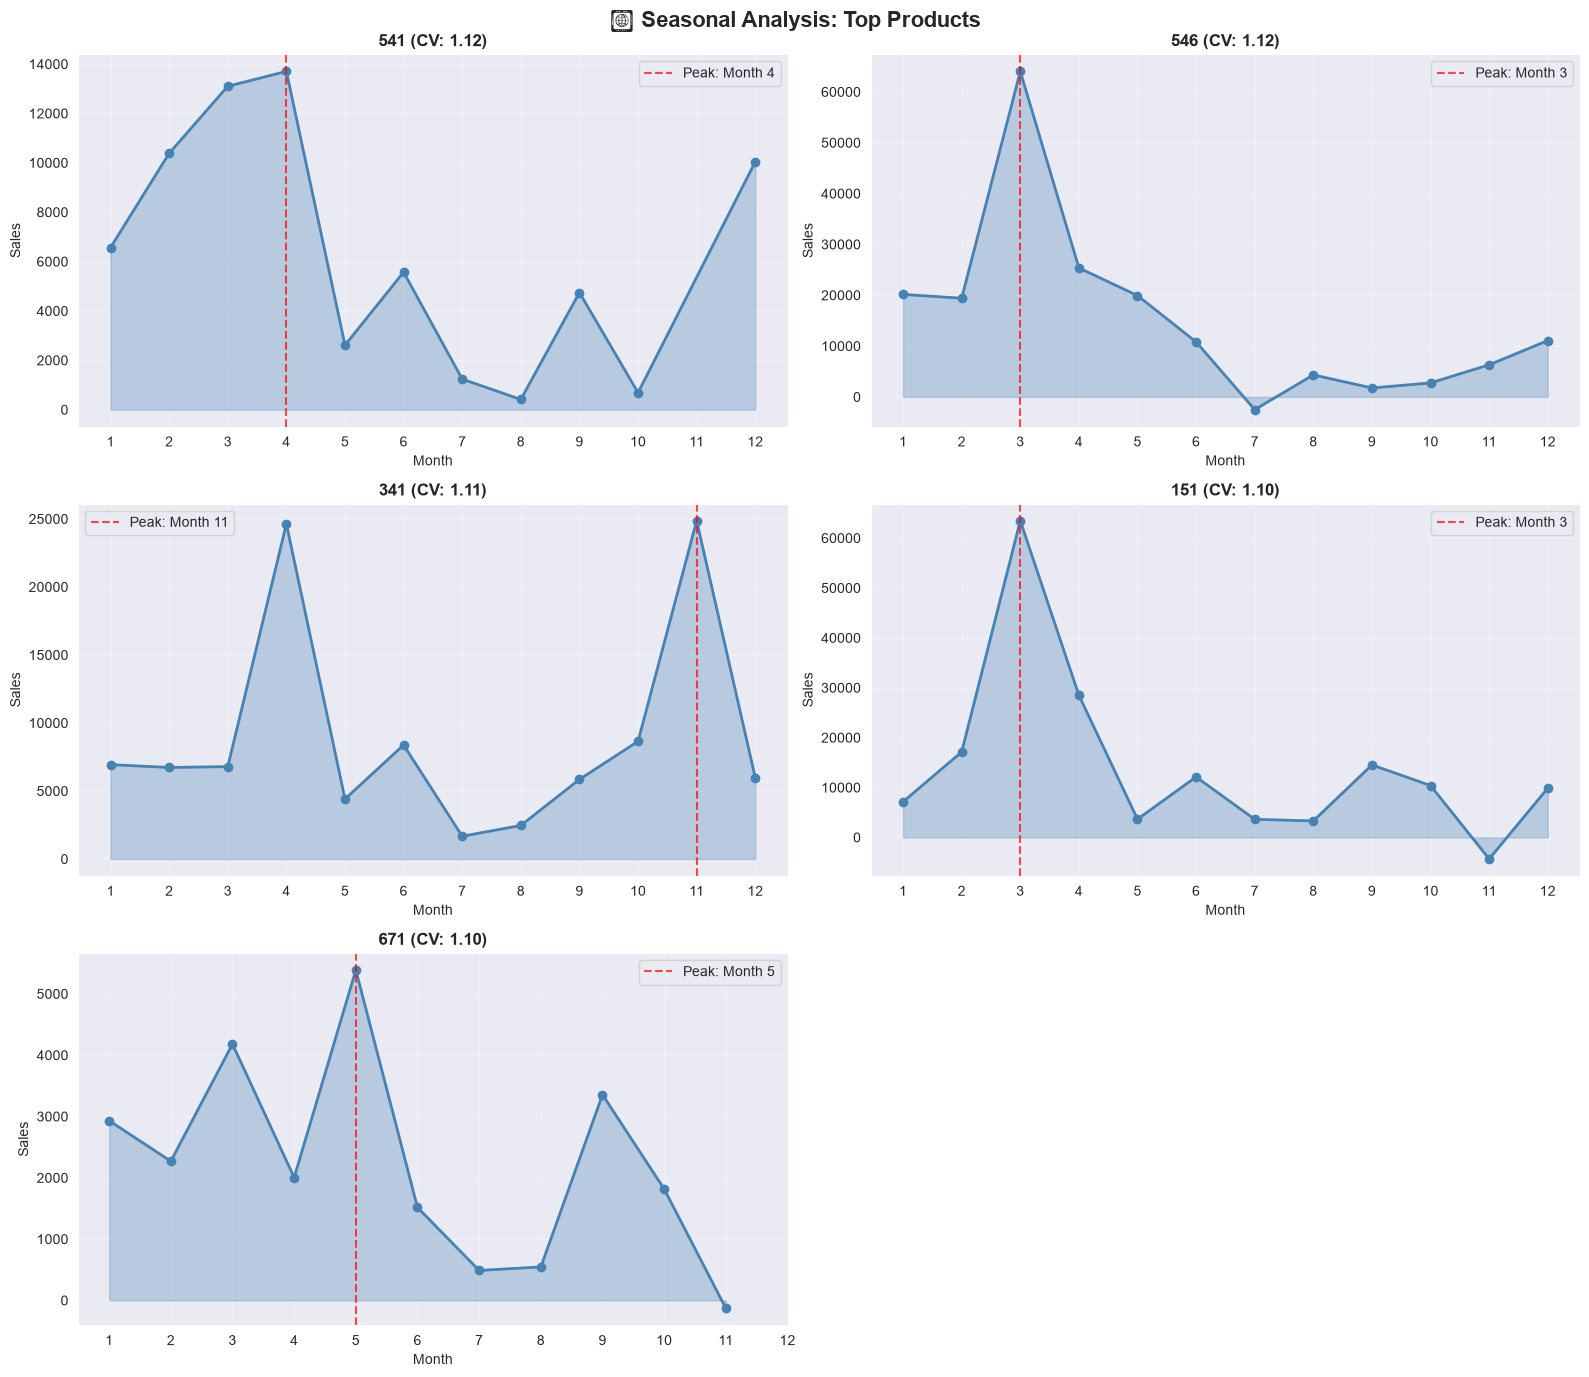

In [52]:

#> Time:
#  - Are there products that sell a lot at certain times (seasonal products)?


# ========== METHOD 1: Coefficient of Variation ==========
# كل ما CV أعلى = المنتج أكثر موسمية

product_monthly = df_time.groupby([df_time.index.to_period('M'), 'ProductKey'])['TotalAmount'].sum().unstack(fill_value=0)

# نحسب معامل التباين لكل منتج
cv_by_product = (product_monthly.std() / product_monthly.mean()).sort_values(ascending=False)

print("🔥 أكثر المنتجات موسمية (أعلى CV):")
print(cv_by_product.head(10))

# ========== METHOD 2: Seasonal Index ==========
# نحسب Seasonal Index = (المبيعات في الشهر / متوسط المبيعات السنوية)

monthly_avg = df_time.groupby(['Month', 'ProductKey'])['TotalAmount'].sum()
annual_avg = df_time.groupby('ProductKey')['TotalAmount'].sum() / 12

seasonal_index = monthly_avg.div(annual_avg, level='ProductKey')

# المنتجات اللي فيها Seasonal Index > 2 في شهر معين = موسمية قوية
strong_seasonal = seasonal_index[seasonal_index > 2].dropna()
print("\n📅 منتجات موسمية قوية (SI > 2):")
print(strong_seasonal.sort_values(ascending=False).head(15))

# ========== METHOD 3: Peak Month Detection ==========
peak_months = df_time.groupby(['Month', 'ProductKey'])['TotalAmount'].sum().groupby('ProductKey').idxmax()
print("\n🏔️ شهر الذروة لكل منتج:")
print(peak_months)

# ========== VISUALIZATION ==========
# اختار Top 5 منتجات موسمية
top_seasonal = cv_by_product.head(5).index

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('📊 Seasonal Analysis: Top Products', fontsize=16, fontweight='bold')

for i, product in enumerate(top_seasonal):
    ax = axes[i // 2, i % 2]
    
    # Monthly trend
    monthly_sales = df_time[df_time['ProductKey'] == product].groupby(df_time[df_time['ProductKey'] == product].index.month)['TotalAmount'].sum()
    
    ax.plot(monthly_sales.index, monthly_sales.values, marker='o', linewidth=2, color='steelblue')
    ax.fill_between(monthly_sales.index, monthly_sales.values, alpha=0.3, color='steelblue')
    ax.set_title(f'{product} (CV: {cv_by_product[product]:.2f})', fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Sales')
    ax.set_xticks(range(1, 13))
    ax.grid(True, alpha=0.3)
    
    # Highlight peak
    peak_month = monthly_sales.idxmax()
    ax.axvline(x=peak_month, color='red', linestyle='--', alpha=0.7, label=f'Peak: Month {peak_month}')
    ax.legend()

# Remove empty subplot
axes[2, 1].remove()

plt.tight_layout()
plt.show()



In [53]:
df_time.columns

Index(['SaleKey', 'DateKey', 'ProductKey', 'BranchKey', 'EmployeeKey',
       'Quantity', 'UnitPrice', 'DiscountRate', 'TotalAmount', 'CostAmount',
       'ProfitAmount', 'OrderStatus', 'PaymentMethod', 'UnitCost', 'Date',
       'Year', 'Quarter', 'Month', 'Day', 'MonthNameAr', 'DayNameAr',
       'IsWeekend', 'IsHoliday', 'BranchName', 'Season'],
      dtype='str')

🔥 أكثر الفروع موسمية:
BranchName
فرع المدينة    0.267353
فرع الرياض     0.249534
فرع جدة        0.242142
فرع مكة        0.237710
فرع الدمام     0.225054
dtype: float64

📅 فروع موسمية قوية (SI > 2):
Series([], Name: TotalAmount, dtype: float64)


C:\Users\abdul\AppData\Local\Temp\ipykernel_9140\238083100.py:36: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.tight_layout()
e:\Data-analysis\Py-Data_analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


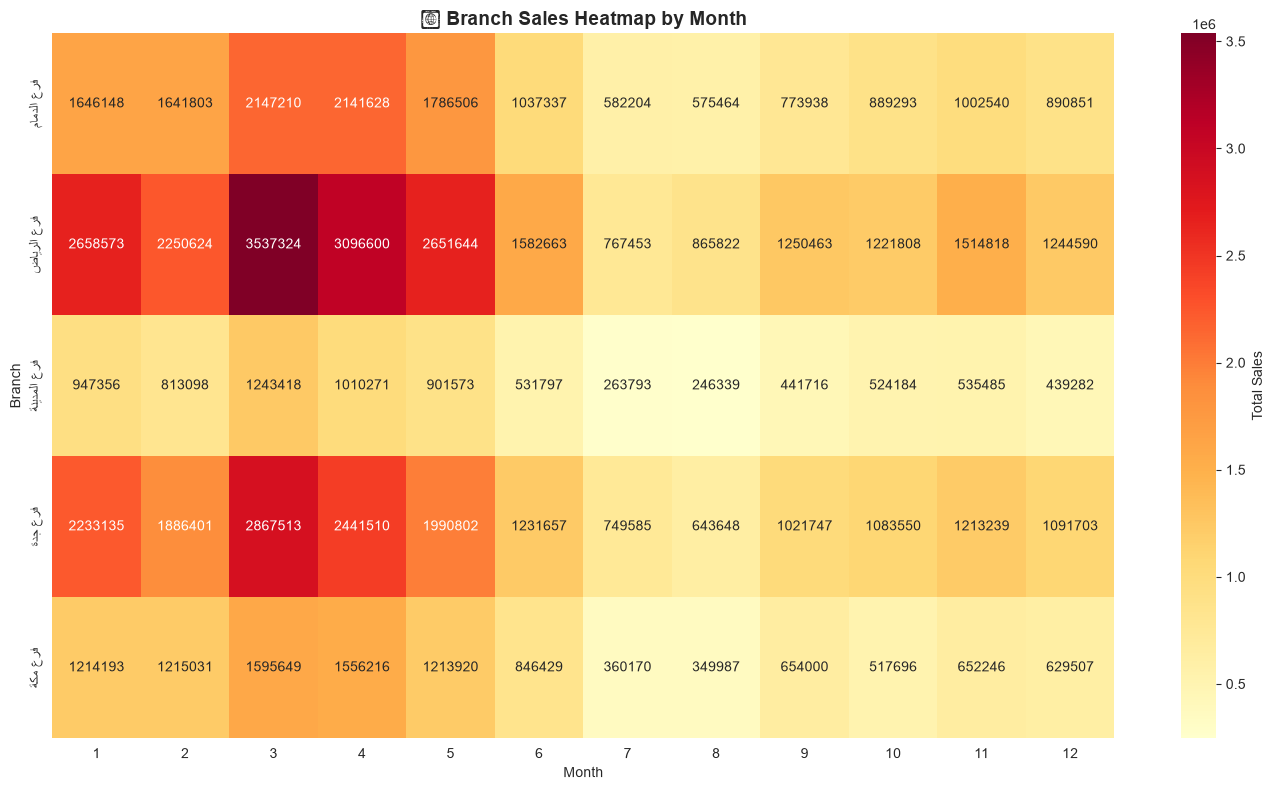

In [54]:

# - Are there branches that achieve sales and profits at certain times (seasonal branches)?



# ========== نفس الطرق للفروع ==========

# CV for branches
branch_monthly = df_time.groupby([df_time.index.to_period('M'), 'BranchName'])['TotalAmount'].sum().unstack(fill_value=0)
cv_by_branch = (branch_monthly.std() / branch_monthly.mean()).sort_values(ascending=False)

print("🔥 أكثر الفروع موسمية:")
print(cv_by_branch)

# Seasonal Index for branches
branch_seasonal = df_time.groupby(['Month', 'BranchName'])['TotalAmount'].sum()
branch_annual = df_time.groupby('BranchName')['TotalAmount'].sum() / 12
branch_si = branch_seasonal.div(branch_annual, level='BranchName')

print("\n📅 فروع موسمية قوية (SI > 2):")
print(branch_si[branch_si > 2].dropna().sort_values(ascending=False).head(15))

# ========== Branch Seasonality Heatmap ==========
pivot_branch = df_time.groupby(['Month', 'BranchName'])['TotalAmount'].sum().unstack()

plt.figure(figsize=(14, 8))
sns.heatmap(
    pivot_branch.T, 
    annot=True, 
    fmt='.0f', 
    cmap='YlOrRd',
    cbar_kws={'label': 'Total Sales'}
)
plt.title('🔥 Branch Sales Heatmap by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Branch')
plt.tight_layout()
plt.show()